In [42]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, gaussian_kde, chi2
from empiricaldist import Cdf, Pmf

from utils import (
    decorate, 
    make_joint, 
    normalize, 
    plot_contour, 
    marginal
)

sns.set_style('darkgrid')
warnings.filterwarnings("ignore")

## 13.1 Improving Reading Ability

In [3]:
df = pd.read_csv('./data/drp_scores.csv', skiprows=21, delimiter='\t')
df.head(3)

,Treatment,Response
0,Treated,24
1,Treated,43
2,Treated,58


In [4]:
grouped = df.groupby('Treatment')
responses = {}

for name, group in grouped:
    responses[name] = group['Response']

In [6]:
responses['Control']

21    42
22    43
23    55
24    26
25    62
26    37
27    33
28    41
29    19
30    54
31    20
32    85
33    46
34    10
35    17
36    60
37    53
38    42
39    37
40    42
41    55
42    28
43    48
Name: Response, dtype: int64

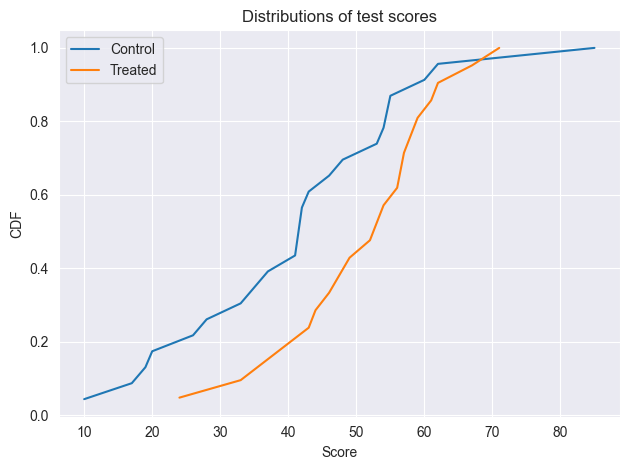

In [10]:
for name, response in responses.items():
    cdf = Cdf.from_seq(response)
    cdf.plot(label=name)
    
decorate(
    xlabel='Score', 
    ylabel='CDF',
    title='Distributions of test scores'
)

## 13.2 Estimating Parameters

In [15]:
def make_uniform(qs, name=None, **options):
    """Make a Pmf that represents a uniform distribution."""
    pmf = Pmf(1.0, qs, **options)
    pmf.normalize()
    if name:
        pmf.index.name = name
    return pmf


qs = np.linspace(20, 80, num=101)
prior_mu = make_uniform(qs, name='mean')

qs = np.linspace(5, 30, num=101)
prior_sigma = make_uniform(qs, name='std')

prior = make_joint(prior_mu, prior_sigma)

In [16]:
data = responses['Control']
data.shape

(23,)

## 13.3 Likelihood

In [17]:
mu_mesh, sigma_mesh, data_mesh = np.meshgrid(
    prior.columns, prior.index, data
)
mu_mesh.shape

(101, 101, 23)

In [19]:
densities = norm(mu_mesh, sigma_mesh).pdf(data_mesh)
densities.shape

(101, 101, 23)

In [21]:
likelihood = densities.prod(axis=2)
print(likelihood.shape)

posterior = prior * likelihood
normalize(posterior)
print(posterior.shape)

(101, 101)
(101, 101)


In [ ]:
def update_norm(prior, data):
    """Update the prior based on data."""
    mu_mesh, sigma_mesh, data_mesh = np.meshgrid(
        prior.columns, prior.index, data
    )
    
    densities = norm(mu_mesh, sigma_mesh).pdf(data_mesh)
    likelihood = densities.prod(axis=2)
    
    posterior = prior * likelihood
    normalize(posterior)

    return posterior


data = responses['Control']
posterior_control = update_norm(prior, data)

data = responses['Treated']
posterior_treated = update_norm(prior, data)

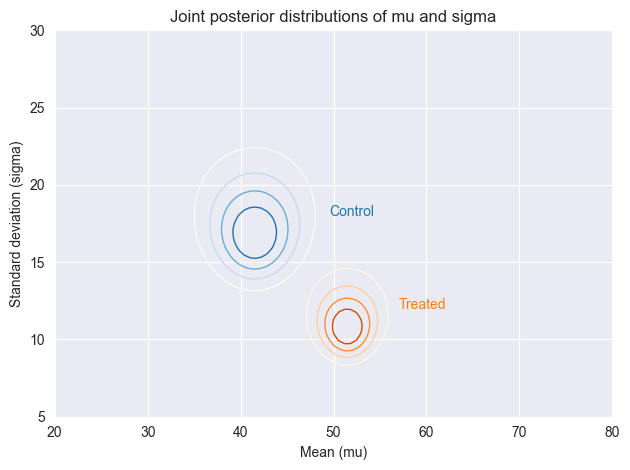

In [26]:
plot_contour(posterior_control, cmap='Blues')
plt.text(49.5, 18, 'Control', color='C0')

cs = plot_contour(posterior_treated, cmap='Oranges')
plt.text(57, 12, 'Treated', color='C1')

decorate(
    xlabel='Mean (mu)', 
    ylabel='Standard deviation (sigma)',
    title='Joint posterior distributions of mu and sigma'
)

## 13.4 Posterior Marginal Distributions

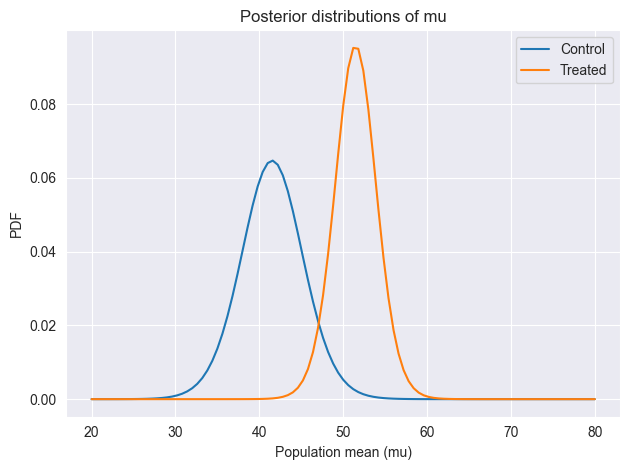

In [28]:
pmf_mean_control = marginal(posterior_control, 0)
pmf_mean_treated = marginal(posterior_treated, 0)

pmf_mean_control.plot(label='Control')
pmf_mean_treated.plot(label='Treated')

decorate(
    xlabel='Population mean (mu)', 
    ylabel='PDF', 
    title='Posterior distributions of mu'
)

In [29]:
Pmf.prob_gt(pmf_mean_treated, pmf_mean_control)

0.980479025187326

## 13.5 Distribution of Differences

In [30]:
pmf_diff = Pmf.sub_dist(pmf_mean_treated, pmf_mean_control)

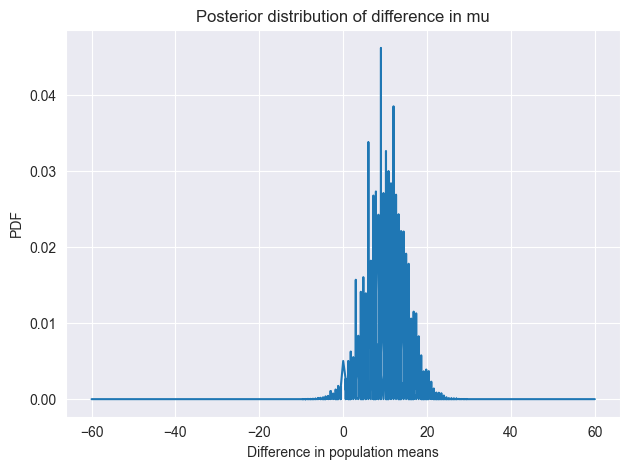

In [31]:
pmf_diff.plot()

decorate(
    xlabel='Difference in population means', 
    ylabel='PDF', 
    title='Posterior distribution of difference in mu'
)

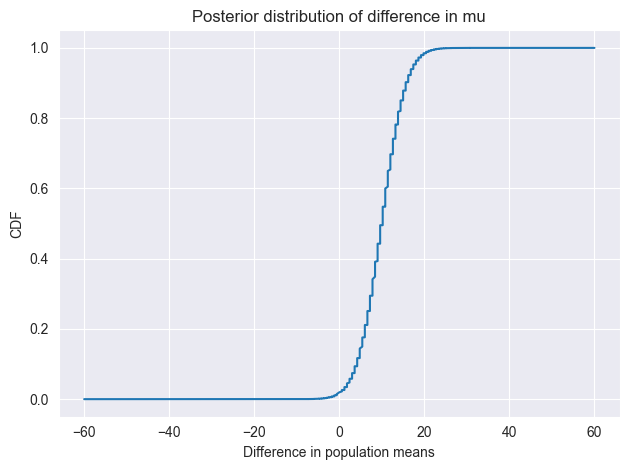

In [ ]:
cdf_diff = pmf_diff.make_cdf()

cdf_diff.plot()

decorate(
    xlabel='Difference in population means', 
    ylabel='CDF', 
    title='Posterior distribution of difference in mu'
)

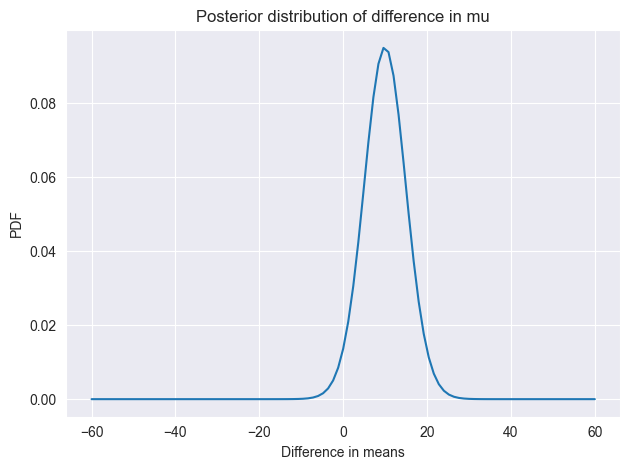

In [ ]:
def kde_from_pmf(pmf, n=101):
    """Make a kernel density estimate for a PMF."""
    kde = gaussian_kde(pmf.qs, weights=pmf.ps)
    qs = np.linspace(pmf.qs.min(), pmf.qs.max(), n)
    ps = kde.evaluate(qs)
    pmf = Pmf(ps, qs)
    pmf.normalize()
    return pmf


kde_diff = kde_from_pmf(pmf_diff)
kde_diff.plot()

decorate(
    xlabel='Difference in means', 
    ylabel='PDF', 
    title='Posterior distribution of difference in mu'
)

In [39]:
print(pmf_diff.mean())
print(pmf_diff.credible_interval(0.9))

9.954413088940848
[ 2.4 17.4]


## 13.6 Using Summary Statistics

In [40]:
mu = 42
sigma = 17

n = 20
m = 41
s = 18

In [41]:
dist_m = norm(mu, sigma / np.sqrt(n))
likelihood_m = dist_m.pdf(m)
likelihood_m

0.10137915138497372

In [43]:
t = n * s**2 / sigma**2
dist_s = chi2(n - 1)
likelihood_s = dist_s.pdf(t)
likelihood_s

0.04736427909437004

In [44]:
joint_likelihood = likelihood_m * likelihood_s
joint_likelihood

0.004801750420548287

## 13.7 Update with Summary Statistics

In [45]:
summary = {}

for name, response in responses.items():
    summary[name] = len(response), response.mean(), response.std()

summary

{'Control': (23, 41.52173913043478, 17.148733229699484),
 'Treated': (21, 51.476190476190474, 11.00735684721381)}

In [46]:
n, m, s = summary['Control']

In [47]:
mus, sigmas = np.meshgrid(prior.columns, prior.index)
mus.shape

(101, 101)

In [48]:
likelihood1 = norm(mus, sigmas/np.sqrt(n)).pdf(m)
likelihood2 = chi2(n - 1).pdf(n * s**2 / sigmas**2)

posterior_control2 = prior * likelihood1 * likelihood2
normalize(posterior_control2)

0.00030965351017402847

In [49]:
def update_norm_summary(prior, data):
    """Update a normal distribution using summary statistics."""
    n, m, s = data
    mu_mesh, sigma_mesh = np.meshgrid(prior.columns, prior.index)
    
    like1 = norm(mu_mesh, sigma_mesh/np.sqrt(n)).pdf(m)
    like2 = chi2(n-1).pdf(n * s**2 / sigma_mesh**2)
    
    posterior = prior * like1 * like2
    normalize(posterior)
    
    return posterior

data = summary['Treated']
posterior_treated2 = update_norm_summary(prior, data)

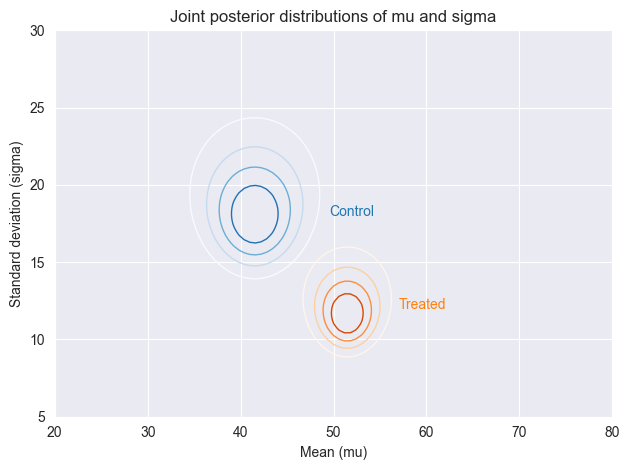

In [50]:
plot_contour(posterior_control2, cmap='Blues')
plt.text(49.5, 18, 'Control', color='C0')

cs = plot_contour(posterior_treated2, cmap='Oranges')
plt.text(57, 12, 'Treated', color='C1')

decorate(
    xlabel='Mean (mu)', 
    ylabel='Standard deviation (sigma)',
    title='Joint posterior distributions of mu and sigma'
)

## 13.8 Comparing Marginals

In [52]:
pmf_mean_control2 = marginal(posterior_control2, 0)
pmf_mean_treated2 = marginal(posterior_treated2, 0)

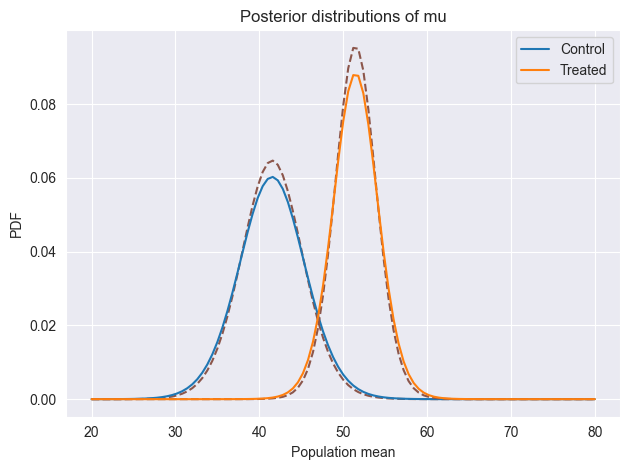

In [53]:
pmf_mean_control.plot(color='C5', ls='--')
pmf_mean_control2.plot(label='Control')
pmf_mean_treated.plot(color='C5', ls='--')
pmf_mean_treated2.plot(label='Treated')

decorate(
    xlabel='Population mean', 
    ylabel='PDF', 
    title='Posterior distributions of mu'
)